<a href="https://colab.research.google.com/github/pedromurcia1232/Week6/blob/main/Actividad6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Actividad 6


## 1. Preparación de Entorno y Datos
Importamos las librerías y generamos el dataset sintético.

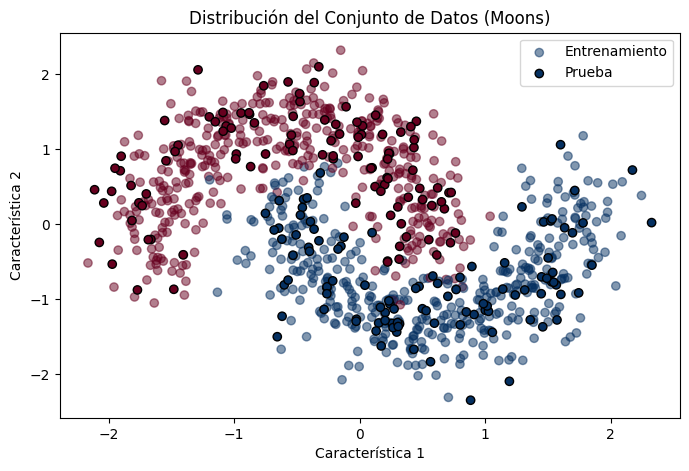

In [ ]:
import numpy as np # Importa numpy para manejo de arreglos numéricos
import matplotlib.pyplot as plt # Importa pyplot para visualización de datos
import tensorflow as tf # Importa el framework de deep learning TensorFlow
from tensorflow.keras import layers, models, regularizers # Componentes para construir redes neuronales
from sklearn.datasets import make_moons # Generador de dataset con forma de medialuna
from sklearn.model_selection import train_test_split # Función para dividir el dataset
from sklearn.preprocessing import StandardScaler # Herramienta para normalizar datos
import pandas as pd # Importa pandas para manejo de tablas de datos

# 1. Generar dataset sintético con ruido para mayor complejidad
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# 2. Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalar los datos: ajusta el escalador con train y transforma ambos conjuntos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Ajusta y transforma entrenamiento
X_test = scaler.transform(X_test) # Transforma prueba usando la media/desviación de train

# 4. Crear la figura para la visualización inicial
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', alpha=0.5, label='Entrenamiento') # Puntos de entrenamiento
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', edgecolors='k', label='Prueba') # Puntos de prueba
plt.title("Distribución del Conjunto de Datos (Moons)") # Título del gráfico en español
plt.xlabel("Característica 1") # Etiqueta eje X
plt.ylabel("Característica 2") # Etiqueta eje Y
plt.legend() # Muestra la leyenda
plt.show() # Despliega el gráfico

## 2. Arquitectura de la Red Neuronal
Definimos los parámetros comunes y creamos las dos configuraciones solicitadas.

In [ ]:
# Definición de hiperparámetros constantes
EPOCHS = 100 # Número de veces que el modelo verá el dataset completo
BATCH_SIZE = 32 # Tamaño del grupo de datos antes de actualizar pesos
LEARNING_RATE = 0.01 # Tasa de aprendizaje para el optimizador

# Función para construir el modelo sin mecanismos de regularización
def crear_modelo_base():
    model = models.Sequential([ # Crea un modelo secuencial capa por capa
        layers.Input(shape=(2,)), # Capa de entrada para 2 coordenadas (X, Y)
        layers.Dense(64, activation='relu'), # Capa oculta 1 con 64 neuronas y ReLU
        layers.Dense(64, activation='relu'), # Capa oculta 2 con 64 neuronas y ReLU
        layers.Dense(1, activation='sigmoid') # Capa de salida para clasificación binaria
    ])
    # Compila definiendo optimizador, función de pérdida y métrica de éxito
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model # Retorna el objeto del modelo

# Función para construir el modelo con L2 y Dropout para evitar sobreajuste
def crear_modelo_reg():
    model = models.Sequential([ # Estructura secuencial
        layers.Input(shape=(2,)), # Entrada de 2 dimensiones
        # Capa con regularización L2 que penaliza pesos grandes
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.3), # Apaga el 30% de las neuronas aleatoriamente para generalizar
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.3), # Segundo Dropout para reforzar la regularización
        layers.Dense(1, activation='sigmoid') # Salida probabilística
    ])
    # Compilación con los mismos parámetros que el modelo base para comparar justamente
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model # Retorna el modelo regularizado

modelo_base = crear_modelo_base() # Instancia el primer modelo
modelo_reg = crear_modelo_reg() # Instancia el segundo modelo

## 3. Entrenar Modelos
Ejecutamos el entrenamiento para ambas configuraciones.

In [ ]:
print("--- Entrenando Modelo Base ---") # Encabezado en consola
# Ejecuta el entrenamiento del modelo base guardando el historial de métricas
history_base = modelo_base.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                               validation_data=(X_test, y_test), verbose=1)

print("\n--- Entrenando Modelo con Regularización ---") # Encabezado en consola
# Ejecuta el entrenamiento del modelo regularizado guardando su historial
history_reg = modelo_reg.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                             validation_data=(X_test, y_test), verbose=1)

--- Entrenando Modelo Base ---
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8500 - loss: 0.3427 - val_accuracy: 0.8750 - val_loss: 0.2494
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9013 - loss: 0.2253 - val_accuracy: 0.9400 - val_loss: 0.1705
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9563 - loss: 0.1420 - val_accuracy: 0.9750 - val_loss: 0.0747
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9650 - loss: 0.0984 - val_accuracy: 0.9850 - val_loss: 0.0572
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9700 - loss: 0.0895 - val_accuracy: 0.9600 - val_loss: 0.0754
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9525 - loss: 0.1065 - val_accuracy: 0.9700 - val_loss: 0.0632
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9675 - loss: 0.0834 - val_accuracy: 0.9700 - val_loss: 0.0684
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9663 - loss: 0

## 4. Visualizar Comportamiento y Métricas
Comparamos las curvas de pérdida y generamos la tabla de resultados.

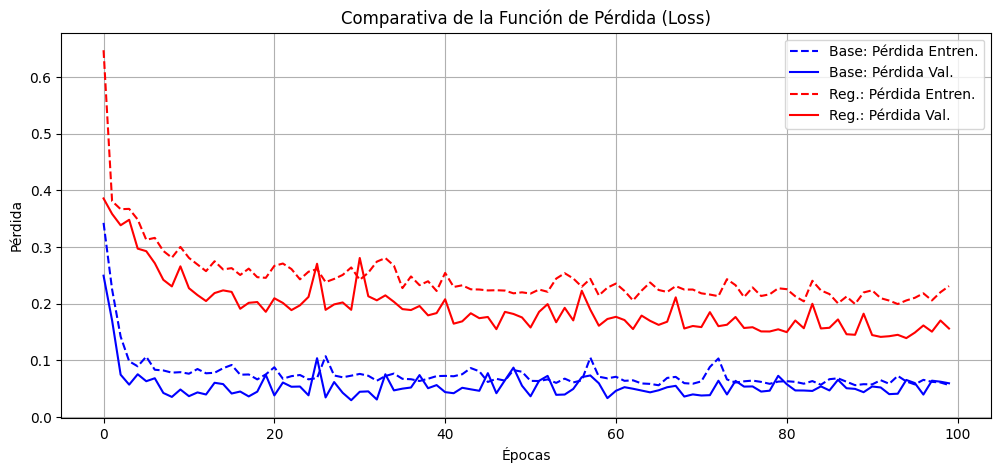

,Métrica,Modelo Base,Modelo Reg
0,Precisión Prueba,0.970000,0.975000
1,Pérdida Final,0.056508,0.231093
2,Iteraciones,100.000000,100.000000
3,Norma L2 Pesos,27.768778,16.790014


In [ ]:
# Configuración de la figura para las gráficas de pérdida
plt.figure(figsize=(12, 5))

# Grafica pérdida de entrenamiento y validación del modelo base
plt.plot(history_base.history['loss'], label='Base: Pérdida Entren.', linestyle='--', color='blue')
plt.plot(history_base.history['val_loss'], label='Base: Pérdida Val.', color='blue')

# Grafica pérdida de entrenamiento y validación del modelo regularizado
plt.plot(history_reg.history['loss'], label='Reg.: Pérdida Entren.', linestyle='--', color='red')
plt.plot(history_reg.history['val_loss'], label='Reg.: Pérdida Val.', color='red')

plt.title("Comparativa de la Función de Pérdida (Loss)") # Título en español
plt.xlabel("Épocas") # Etiqueta eje X
plt.ylabel("Pérdida") # Etiqueta eje Y
plt.legend() # Muestra etiquetas de cada línea
plt.grid(True) # Activa la cuadrícula
plt.show() # Despliega la gráfica

# Función para extraer y calcular la magnitud L2 de los pesos del modelo
def calcular_norma_l2(model):
    total_l2 = 0 # Inicializa el acumulador
    for layer in model.layers: # Recorre cada capa
        if hasattr(layer, 'weights') and len(layer.weights) > 0: # Verifica si tiene pesos ajustables
            weights = layer.get_weights()[0] # Obtiene la matriz de pesos (sin sesgos)
            total_l2 += np.sum(np.square(weights)) # Suma el cuadrado de todos los elementos
    return np.sqrt(total_l2) # Retorna la raíz cuadrada de la suma (Norma L2)

# Estructura de diccionario para crear el DataFrame comparativo
metrics = {
    "Métrica": ["Precisión Prueba", "Pérdida Final", "Iteraciones", "Norma L2 Pesos"],
    "Modelo Base": [
        modelo_base.evaluate(X_test, y_test, verbose=0)[1], # Evalúa precisión en test
        history_base.history['loss'][-1], # Obtiene la última pérdida registrada
        len(history_base.history['loss']), # Cuenta total de épocas
        calcular_norma_l2(modelo_base) # Calcula norma de pesos base
    ],
    "Modelo Reg": [
        modelo_reg.evaluate(X_test, y_test, verbose=0)[1], # Evalúa precisión en test
        history_reg.history['loss'][-1], # Obtiene la última pérdida registrada
        len(history_reg.history['loss']), # Cuenta épocas
        calcular_norma_l2(modelo_reg) # Calcula norma de pesos regularizados
    ]
}

display(pd.DataFrame(metrics)) # Muestra la tabla de resultados

## 5. Límites de Decisión
Visualizamos cómo cada modelo separa las clases.

2321/2321 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


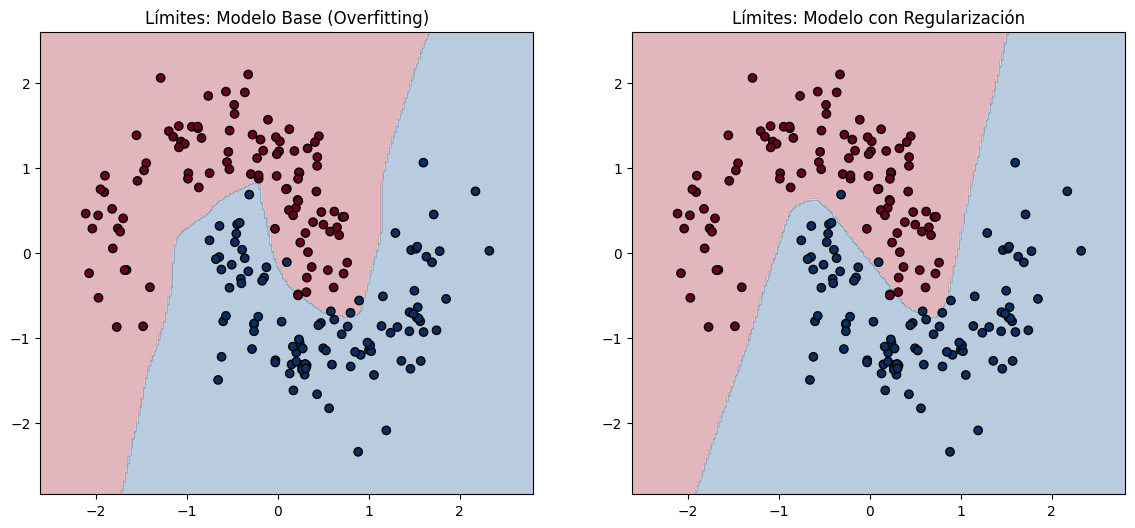

In [ ]:
# Función para visualizar las áreas de decisión de los modelos
def plot_decision_boundary(model, X, y, title):
    # Define límites del plano con margen de 0.5
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    # Crea una rejilla de puntos (mesh) para predecir toda el área
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    # Predice la clase para cada punto de la rejilla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int) # Convierte probabilidad en clase binaria (0 o 1)
    Z = Z.reshape(xx.shape) # Reestructura al formato de la rejilla

    # Dibuja los contornos rellenos representando las áreas de decisión
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    # Dibuja los puntos reales del dataset sobre las áreas
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
    plt.title(title) # Título del subplot

# Configura visualización lado a lado (1 fila, 2 columnas)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1) # Selecciona el primer cuadrante
plot_decision_boundary(modelo_base, X_test, y_test, "Límites: Modelo Base (Overfitting)")
plt.subplot(1, 2, 2) # Selecciona el segundo cuadrante
plot_decision_boundary(modelo_reg, X_test, y_test, "Límites: Modelo con Regularización")
plt.show() # Muestra la comparación visual final

## 6. Análisis y Conclusiones

### (i) **Evidencia de Overfitting**
   El **Modelo Base** suele mostrar una curva de pérdida de validación que comienza a subir mientras la de entrenamiento baja, lo que indica que está memorizando el ruido. En el gráfico de límites, se ven fronteras más erráticas.

### (ii) **Efecto de la Regularización**
   El **Modelo Reg** (Dropout y L2) mantiene las curvas de entrenamiento y validación más cercanas. La norma L2 de los pesos es significativamente menor, lo que significa que los pesos están más controlados y no dependen excesivamente de pocos atributos.

### (iii) **Trade-offs**
   La regularización mejora la **estabilidad** y la **generalización** ante datos nuevos. Sin embargo, puede requerir más épocas para converger o resultar en una precisión ligeramente menor en el set de entrenamiento a cambio de un mejor desempeño en el mundo real.